# Formative 2 – PCA
## Part 2: Choosing the number of components and making PCA faster

This notebook continues from `PCA_Formative2_Person1.ipynb`. Part 1 cleaned the Rwanda Seasonal Agricultural
Survey (2024 Season B) data and did PCA by hand. Here we do:

* **Task 2** – pick the number of principal components from the explained variance
* **Task 3** – make the PCA code faster and test it on bigger data

We only use `numpy` and `matplotlib`. The file is read with Python's built-in `csv` module.

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the clean data from Part 1
`data/processed/sas_2024B_pca_ready.csv` has no missing values and every column is already a number.

In [2]:
with open("data/processed/sas_2024B_pca_ready.csv") as f:
    reader = csv.reader(f)
    feature_names = next(reader)
    X = np.array([[float(v) for v in row] for row in reader])

print("Shape:", X.shape)
print("Missing values:", np.isnan(X).sum())
print("Features:", feature_names)

Shape: (17260, 20)
Missing values: 0
Features: ['age', 'area', 'labour_cost', 'erosion_cost', 'irrigation_cost', 'erosion_level', 'anti_erosion', 'consolidated', 'machine', 'irrigated', 'gender_Female', 'gender_Organisation', 'province_East', 'province_North', 'province_South', 'province_West', 'stratum_large farm', 'stratum_marshland', 'stratum_mixed', 'stratum_rangeland']


## 2. Scale and run PCA (same steps as Part 1)
We z-score every column so that no feature wins just because of its units, then get the sorted eigenvalues
and eigenvectors of the covariance matrix.

In [3]:
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

X_centered = X_scaled - X_scaled.mean(axis=0)
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues (largest first):", eigenvalues.round(3))

Eigenvalues (largest first): [3.752 1.728 1.33  1.255 1.13  1.09  1.055 1.023 1.003 0.916 0.892 0.848
 0.842 0.784 0.764 0.668 0.339 0.284 0.232 0.065]


---
# Task 2: How many principal components?
### Step 1: Explained variance
Each eigenvalue is the variance along its principal component. Dividing it by the sum of all eigenvalues gives the
share of the total variance that the component explains. The cumulative sum tells us how much we keep if we use
the first k components.

In [4]:
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

print(f"{'PC':<6}{'eigenvalue':>11}{'explained':>11}{'cumulative':>12}")
for i in range(len(eigenvalues)):
    print(f"PC{i+1:<4}{eigenvalues[i]:>11.3f}{explained[i]*100:>10.1f}%{cumulative[i]*100:>11.1f}%")

PC     eigenvalue  explained  cumulative
PC1         3.752      18.8%       18.8%
PC2         1.728       8.6%       27.4%
PC3         1.330       6.6%       34.0%
PC4         1.255       6.3%       40.3%
PC5         1.130       5.7%       46.0%
PC6         1.090       5.4%       51.4%
PC7         1.055       5.3%       56.7%
PC8         1.023       5.1%       61.8%
PC9         1.003       5.0%       66.8%
PC10        0.916       4.6%       71.4%
PC11        0.892       4.5%       75.9%
PC12        0.848       4.2%       80.1%
PC13        0.842       4.2%       84.3%
PC14        0.784       3.9%       88.2%
PC15        0.764       3.8%       92.1%
PC16        0.668       3.3%       95.4%
PC17        0.339       1.7%       97.1%
PC18        0.284       1.4%       98.5%
PC19        0.232       1.2%       99.7%
PC20        0.065       0.3%      100.0%


### Step 2: Scree plot and cumulative explained variance
The bars show how much each component explains on its own. The line shows the running total.

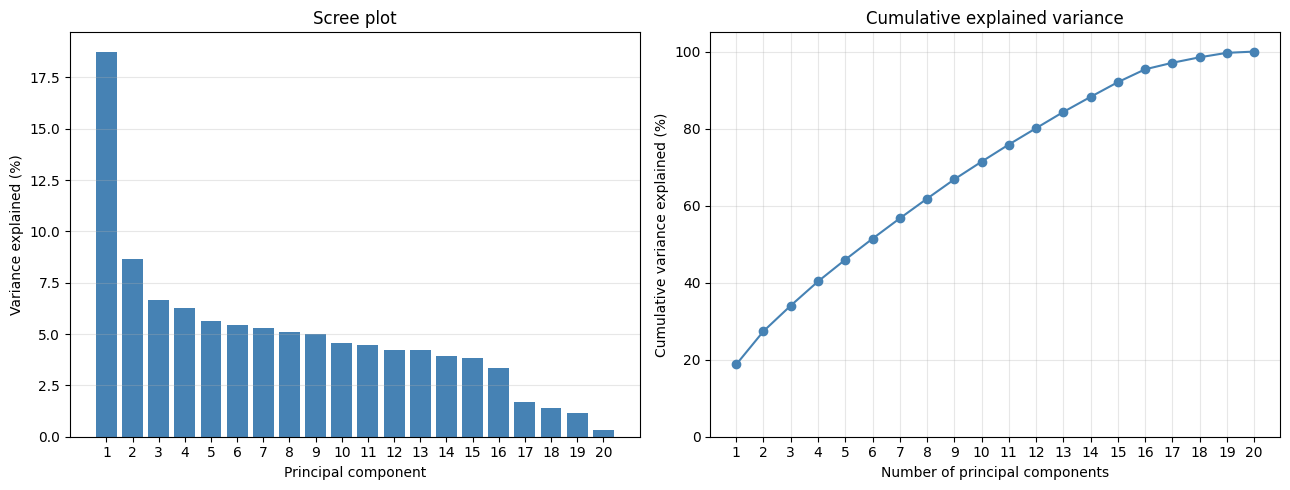

In [5]:
pcs = np.arange(1, len(eigenvalues) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(pcs, explained * 100, color="steelblue")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained (%)")
ax1.set_title("Scree plot")
ax1.set_xticks(pcs)
ax1.grid(alpha=0.3, axis="y")

ax2.plot(pcs, cumulative * 100, marker="o", color="steelblue")
ax2.set_xlabel("Number of principal components")
ax2.set_ylabel("Cumulative variance explained (%)")
ax2.set_title("Cumulative explained variance")
ax2.set_xticks(pcs)
ax2.set_ylim(0, 105)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/explained_variance.png")
plt.show()

### Step 3: Pick k dynamically
Instead of fixing k by hand, we give a target share of variance to keep and let the code find the smallest k
that reaches it. If the data changes, k changes with it.

In [6]:
def choose_k(eigenvalues, threshold):
    """Smallest number of components whose cumulative explained variance reaches the threshold."""
    cumulative = np.cumsum(eigenvalues) / eigenvalues.sum()
    return int(np.argmax(cumulative >= threshold)) + 1

for t in [0.80, 0.90, 0.95]:
    k_t = choose_k(eigenvalues, t)
    print(f"Keep {t*100:.0f}% of variance -> k = {k_t:<3} ({cumulative[k_t-1]*100:.1f}% kept, "
          f"{len(eigenvalues) - k_t} of {len(eigenvalues)} dimensions dropped)")

Keep 80% of variance -> k = 12  (80.1% kept, 8 of 20 dimensions dropped)
Keep 90% of variance -> k = 15  (92.1% kept, 5 of 20 dimensions dropped)
Keep 95% of variance -> k = 16  (95.4% kept, 4 of 20 dimensions dropped)


In [7]:
threshold = 0.90   # the share of variance we want to keep
k = choose_k(eigenvalues, threshold)

print("Chosen threshold:", threshold)
print("Chosen k:", k)
print(f"Variance kept: {cumulative[k-1]*100:.1f}%   Variance lost: {(1 - cumulative[k-1])*100:.1f}%")

Chosen threshold: 0.9
Chosen k: 15
Variance kept: 92.1%   Variance lost: 7.9%


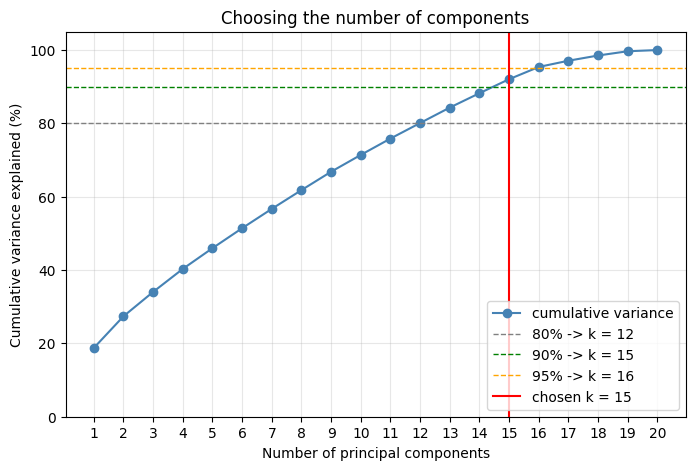

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(pcs, cumulative * 100, marker="o", color="steelblue", label="cumulative variance")

for t, c in [(0.80, "gray"), (0.90, "green"), (0.95, "orange")]:
    plt.axhline(t * 100, color=c, linestyle="--", linewidth=1, label=f"{t*100:.0f}% -> k = {choose_k(eigenvalues, t)}")

plt.axvline(k, color="red", linewidth=1.5, label=f"chosen k = {k}")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative variance explained (%)")
plt.title("Choosing the number of components")
plt.xticks(pcs)
plt.ylim(0, 105)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("figures/choosing_k.png")
plt.show()

### Step 4: Project the data onto the k components

In [9]:
W = eigenvectors[:, :k]
X_pca = X_centered @ W

print("Before:", X_centered.shape)
print("After: ", X_pca.shape)
print("Variance of each new column matches its eigenvalue:",
      np.allclose(X_pca.var(axis=0, ddof=1), eigenvalues[:k]))

Before: (17260, 20)
After:  (17260, 15)
Variance of each new column matches its eigenvalue: True


### Step 5: What information is lost?
We rebuild the data from the k components (`X_pca @ W.T`) and compare it with the original. For each feature, the
share of its variance that we cannot rebuild is the information the dropped components carried about that feature.

In [10]:
X_rebuilt = X_pca @ W.T
error = X_centered - X_rebuilt

lost_total = (error ** 2).sum() / (X_centered ** 2).sum()
print(f"Total variance lost: {lost_total*100:.1f}%  (same as 1 - cumulative[k-1] = {(1 - cumulative[k-1])*100:.1f}%)")

lost_per_feature = error.var(axis=0) / X_centered.var(axis=0)
order_lost = np.argsort(lost_per_feature)[::-1]

print("\nShare of each feature's variance lost (largest first):")
for j in order_lost:
    print(f"  {feature_names[j]:<22} {lost_per_feature[j]*100:5.1f}%")

Total variance lost: 7.9%  (same as 1 - cumulative[k-1] = 7.9%)

Share of each feature's variance lost (largest first):
  consolidated            37.2%
  stratum_large farm      22.9%
  gender_Organisation     22.7%
  area                    21.2%
  irrigated               15.5%
  irrigation_cost         14.4%
  machine                  5.6%
  province_East            4.7%
  province_West            2.9%
  stratum_rangeland        1.9%
  province_South           1.8%
  province_North           1.5%
  age                      1.4%
  stratum_marshland        1.3%
  gender_Female            1.2%
  labour_cost              1.1%
  erosion_cost             0.9%
  anti_erosion             0.3%
  stratum_mixed            0.3%
  erosion_level            0.0%


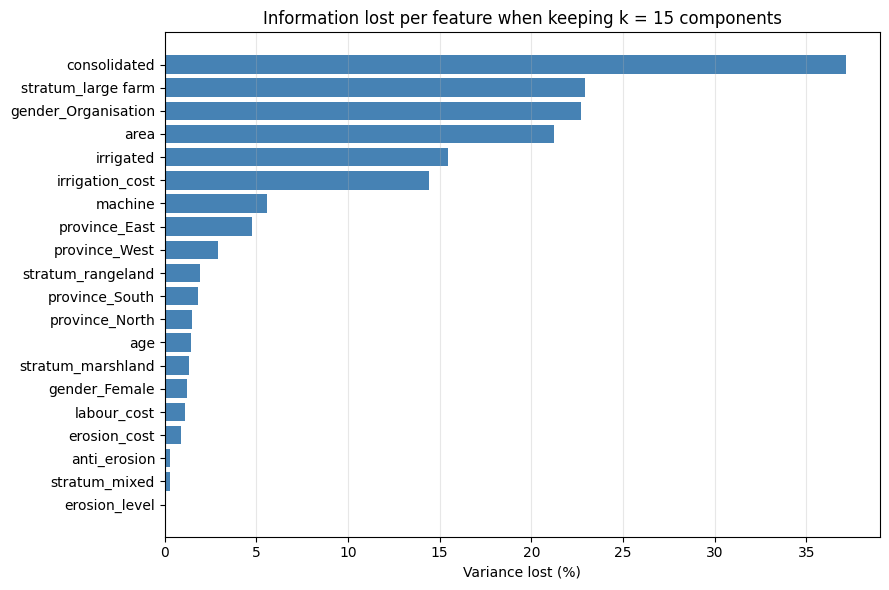

In [11]:
plt.figure(figsize=(9, 6))
plt.barh([feature_names[j] for j in order_lost][::-1], lost_per_feature[order_lost][::-1] * 100, color="steelblue")
plt.xlabel("Variance lost (%)")
plt.title(f"Information lost per feature when keeping k = {k} components")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("figures/information_lost.png")
plt.show()

In [12]:
dropped = eigenvectors[:, k:]

print(f"Features with the biggest weights in the dropped components (PC{k+1} to PC{len(eigenvalues)}):")
for i in range(dropped.shape[1]):
    top = np.argsort(np.abs(dropped[:, i]))[::-1][:3]
    names = ", ".join(f"{feature_names[j]} ({dropped[j, i]:+.2f})" for j in top)
    print(f"  PC{k+i+1:<3} ({explained[k+i]*100:.1f}%): {names}")

Features with the biggest weights in the dropped components (PC16 to PC20):
  PC16  (3.3%): consolidated (-0.73), gender_Organisation (+0.33), stratum_large farm (+0.32)
  PC17  (1.7%): area (-0.58), irrigated (+0.49), gender_Organisation (+0.41)
  PC18  (1.4%): stratum_large farm (-0.67), gender_Organisation (+0.58), irrigation_cost (+0.29)
  PC19  (1.2%): area (+0.64), irrigation_cost (-0.52), irrigated (+0.40)
  PC20  (0.3%): province_East (-0.54), province_South (-0.52), province_West (-0.49)


### Why this number of components? (written by us)

✍️ **YOUR EXPLANATION HERE** – write this yourself, based on the numbers above. The brief asks for:

* **Why k:** why did you pick this threshold and this k?
* **Tradeoff:** what do you gain (fewer dimensions, simpler data) and what do you give up?
* **Information lost:** in terms of the farm plots, which practices or groups of plots does the reduced data
  describe worse? Use the "information lost per feature" chart and the dropped components list.

---
# Task 3: Making PCA faster and able to handle large data
### Step 1: The original version
These are the same steps as Part 1 in one function: scale, center, covariance, eigen decomposition, sort, project.
Every step makes a new full-size copy of the data (`X - mean`, `/ std`, `- mean` again), so for n rows it
holds several n × 20 arrays in memory at the same time.

In [13]:
def pca_original(X, k):
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    X_centered = X_scaled - X_scaled.mean(axis=0)
    cov_matrix = (X_centered.T @ X_centered) / (X.shape[0] - 1)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    return X_centered @ eigenvectors[:, :k], eigenvalues

### Step 2: The optimized version
Changes:

1. **Read the data in chunks, once.** For each chunk we only add up the column sums and `chunk.T @ chunk`
   (a 20 × 20 matrix). From these totals we get the mean, the standard deviation and the covariance, without ever
   making a scaled or centered copy of the whole dataset. Memory for this part stays the same no matter how many
   rows there are.
2. **Scale inside the eigenvectors instead of the data.** Scaling and centering is
   `(X - mean) / std @ W`, which equals `X @ (W / std) - (mean / std) @ W`. So we change the small 20 × k matrix
   once, and project each chunk directly.
3. **No `argsort`.** `np.linalg.eigh` already returns eigenvalues from smallest to largest, so we just reverse
   them.
4. **Only keep k eigenvectors** and write the projected chunks straight into one output array.

In [14]:
def pca_optimized(X, k, chunk_size=50_000):
    n, d = X.shape

    # One pass over the data: column sums and X.T @ X, chunk by chunk
    col_sum = np.zeros(d)
    xtx = np.zeros((d, d))
    for start in range(0, n, chunk_size):
        chunk = X[start:start + chunk_size]
        col_sum += chunk.sum(axis=0)
        xtx += chunk.T @ chunk

    mean = col_sum / n
    cov_raw = (xtx - n * np.outer(mean, mean)) / (n - 1)
    std = np.sqrt(np.diag(cov_raw) * (n - 1) / n)     # same as X.std(axis=0)
    cov_matrix = cov_raw / np.outer(std, std)         # covariance of the scaled data

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    eigenvalues = eigenvalues[::-1]
    W = eigenvectors[:, ::-1][:, :k]

    # Put the scaling into W, then project chunk by chunk
    W_scaled = W / std[:, None]
    shift = (mean / std) @ W
    X_pca = np.empty((n, k))
    for start in range(0, n, chunk_size):
        X_pca[start:start + chunk_size] = X[start:start + chunk_size] @ W_scaled - shift
    return X_pca, eigenvalues

### Step 3: Check that both give the same answer

In [15]:
pca_a, eig_a = pca_original(X, k)
pca_b, eig_b = pca_optimized(X, k)

print("Same eigenvalues:", np.allclose(eig_a, eig_b))
print("Same projected data:", np.allclose(pca_a, pca_b))
print("Largest difference:", np.abs(pca_a - pca_b).max())
print("Same as Task 2 result:", np.allclose(pca_b, X_pca))

Same eigenvalues: True
Same projected data: True
Largest difference: 2.1596058275008545e-11
Same as Task 2 result: True
